In [1]:
import gpflow as gpf
from atkernel import TransferKernel
import tensorflow as tf
import numpy as np
import sys
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from atlikelihood import TransferLikelihood

from gpflow.covariances.dispatch import Kuf, Kuu
from gpflow.utilities import to_default_float, assert_params_false, add_likelihood_noise_cov
from gpflow.config import default_jitter, default_float
from gpflow.utilities import to_default_float
from gpflow.models.util import InducingPointsLike, data_input_to_tensor, inducingpoint_wrapper
from gpflow.inducing_variables import InducingPoints
from typing import NamedTuple


from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()


2026-05-04 17:28:34.589923: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 17:28:34.592356: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 17:28:34.649965: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-04 17:28:34.651685: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 17:28:35.368115: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

[  0  15  30  45  60  75  90 105 120 135 150 165 180 195 210 225 240 255
 270 285]


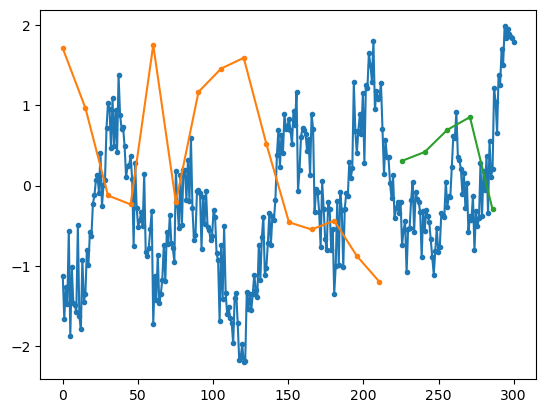

In [2]:
k = gpf.kernels.RBF(lengthscales=10, variance=1) #+ gpf.kernels.Linear(0.001)
Xall = np.linspace(0, 300, 300)
Yall  = np.random.multivariate_normal(np.zeros_like(Xall), k(Xall.reshape(-1, 1)))
ind_1 = np.arange(0, 300, 1)
ind_2 = np.array([i for i in ind_1 if i % 15 == 0])
ind_1 = ind_1[0:300]
ind_2 = ind_2 
print(ind_2)
TEST_INDEX = int(0.75*len(ind_2))
ind_train, ind_test = ind_2[:TEST_INDEX], ind_2[TEST_INDEX:]
X1, y1 = Xall[ind_1], Yall[ind_1]
X2, y2 = Xall[ind_train], Yall[ind_train]
X2 = X2 - X2[0]
y2 = -y1 # np.roll(y2, 5)
y2 = y2[ind_train]
Xtest, ytest = Xall[ind_test], Yall[ind_test]
ytest = -ytest.reshape(-1, 1) + np.random.normal(0, 0.5, len(Xtest)).reshape(-1, 1)

y1 = y1.reshape(-1, 1) + np.random.normal(0, 0.3, len(X1)).reshape(-1, 1)
y2 = y2.reshape(-1, 1) + np.random.normal(0, 0.5, len(X2)).reshape(-1, 1) 
X1 = X1.reshape(-1, 1)
X2 = X2.reshape(-1, 1)
y2 = y2 
plt.plot(X1, y1, marker=".")
plt.plot(X2, y2, marker=".")
plt.plot(Xtest, ytest, marker=".")
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
plt.show()
X = tf.cast(X, np.float64)
y = tf.cast(y, np.float64)

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[1].W        

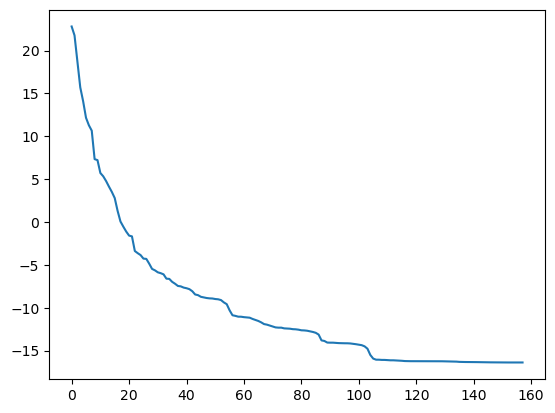

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.008159872145765284    │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 6.41106                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─

In [3]:


output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
probs = np.array([len(ind_1), len(ind_2)])/(len(ind_2) + len(ind_1))
ivs = np.linspace(0, len(Xall), 100).reshape(-1, 1)
iv_ind = np.random.permutation(np.concatenate( (np.zeros((int(len(ivs)/2), 1)), np.ones((int(len(ivs)/2), 1)) ), axis=0))
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg
m = SparseCMOGP((X, y), exact_target=True, kernel=kern, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)

In [4]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(8, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    (line,) = plt.plot(X1, Y1, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y1")

    (line,) = plt.plot(X2, Y2, "x", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, line.get_color(), "Y2")
    ivs = m.inducing_variable.Z.numpy() 
    plt.scatter(ivs, np.zeros_like(ivs))
    plt.legend()
    return np.mean((mu - Xtest) ** 2)
 

### Ours

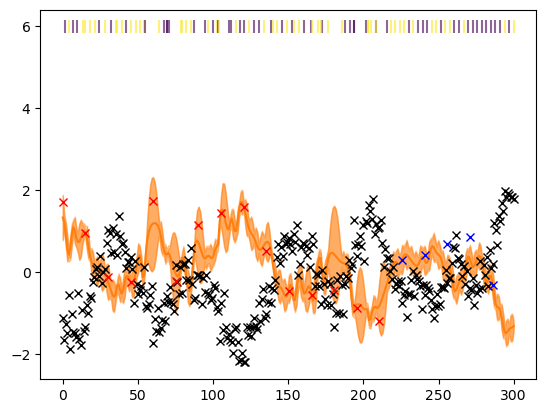

0.13411296209878296

In [5]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*6, marker="|", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════╧═══════════╧══════════════════╧═════════╧═════════════╧═════════╧════

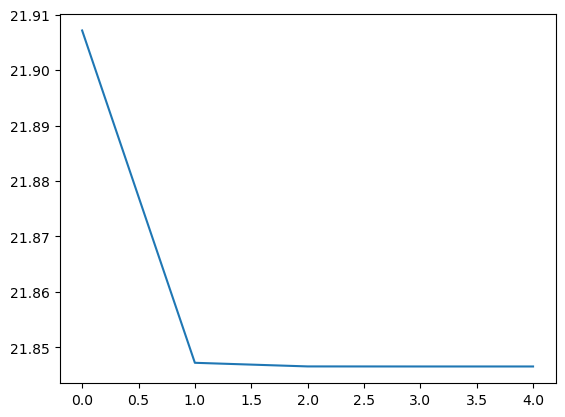

In [6]:
kern = gpf.kernels.Matern32()
m = gpf.models.GPR((X2, y2), kernel=kern)
gpf.utilities.print_summary(m)
optimize(m)

### Regular GP

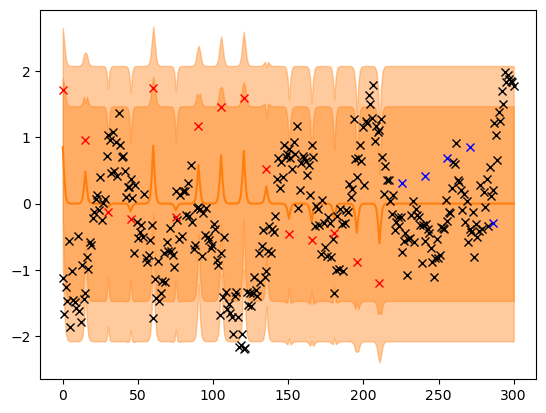

0.3125298435457363

In [7]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = Xall
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.show()

regular_gp_mse = mean_squared_error(ytest, fmean_tst)
regular_gp_mse

### Comparison with exact MOGP

In [8]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.VGP((X, y), kernel=kern, likelihood=lik)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 147.00176847636698
        x: [-1.310e+00 -2.324e-01 ... -2.310e+00 -1.265e+00]
      nit: 760
      jac: [ 3.097e-03  4.517e-04 ... -1.735e-05 -3.003e-04]
     nfev: 799
     njev: 799
 hess_inv: <50093x50093 LbfgsInvHessProduct with dtype=float64>

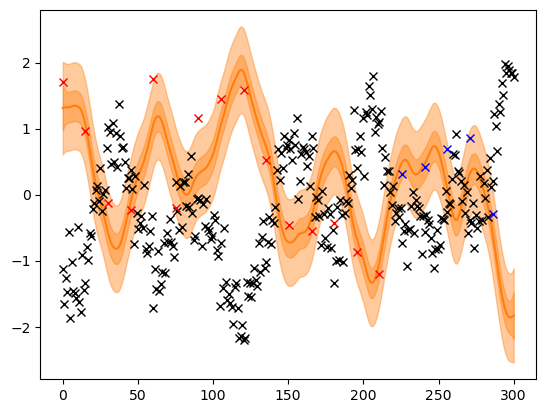

0.15226456072215916

In [9]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)

plt.show()

exact_mogp_mse = mean_squared_error(ytest, fmean_tst)
exact_mogp_mse


In [10]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)

probs = np.array([len(ind_1), len(ind_2)])/(len(ind_2) + len(ind_1))
ivs = np.linspace(0, len(Xall), 100).reshape(-1, 1)
ivs = np.hstack((ivs, np.random.choice([0, 1], p=[0.5, 0.5], size=len(ivs)).reshape(-1, 1)))

X = np.vstack((np.hstack((X1, np.zeros_like(X1))), np.hstack((X2, np.ones_like(X2)))))
y = np.vstack((np.hstack((y1, np.zeros_like(y1))), np.hstack((y2, np.ones_like(y2)))))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-05-04 17:29:22.336454: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-05-04 17:29:22.371470: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 148.32163051831196
        x: [-1.307e+00 -1.984e-01 ... -2.282e+00 -1.259e+00]
      nit: 2152
      jac: [ 4.165e-03  2.346e-03 ...  1.817e-05 -1.357e-04]
     nfev: 2233
     njev: 2233
 hess_inv: <5358x5358 LbfgsInvHessProduct with dtype=float64>

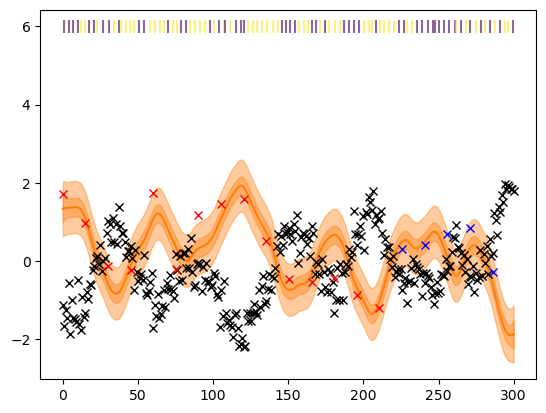

0.1545708201787218

In [11]:
from sklearn.metrics import mean_squared_error
Xall = Xall.reshape(-1, 1)
Xtst = Xtest.reshape(-1, 1)
Xplot = np.hstack((Xall, np.ones_like(Xall)))
Xtst = np.hstack((Xtst, np.ones_like(Xtst)))
fmean, fvar = m.predict_f(Xplot)
fmean_tst, fvar_tst = m.predict_f(Xtst)
ymean, yvar = m.predict_y(Xplot)
plt.plot(Xall, fmean, color="C1")
plt.plot(X1, y1, "kx")
plt.plot(X2, y2, "rx")
plt.plot(Xtest, ytest, "bx")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.fill_between(
    Xall[:, 0],
    (ymean - 2 * np.sqrt(yvar))[:, 0],
    (ymean + 2 * np.sqrt(yvar))[:, 0],
    color="C1",
    alpha=0.4,
)
plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs)[:,0]*6, marker="|", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()

approximate_mogp_mse = mean_squared_error(ytest, fmean_tst)
approximate_mogp_mse

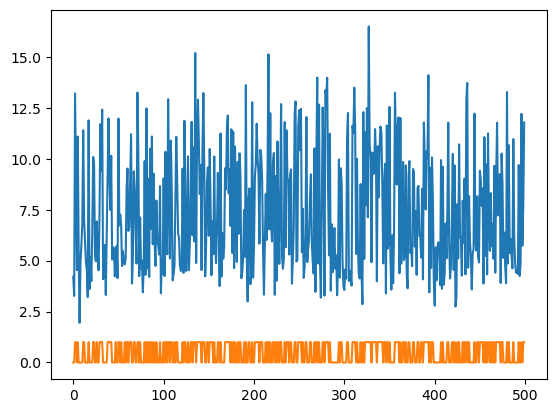

In [12]:
import numpy as np


B = np.random.binomial(1, 0.5, 500)
A = np.where(B == 0, 
             np.random.normal(5, 1, 500),     
             np.random.normal(10, 2, 500)) 

plt.plot(A)
plt.plot(B)   

In [13]:
print(ours_mse)
print(regular_gp_mse)
print(exact_mogp_mse)
print(approximate_mogp_mse)

0.13411296209878296
0.3125298435457363
0.15226456072215916
0.1545708201787218
